# Sampling Big Data for Exploratory Data Analysis

Generally, it is unnecessary and not good practice to carry out the majority of data analysis on a full dataset, especially if it is very large (~ 10 million rows+). In the exploratory data analysis (EDA), deatiled analysis and development phases of your work it is suggested that you keep the size of your data as small as possible to conserve compute resource, time and money. Ideally, you should take a sample small enough that you can work in Python or R instead of PySpark and SparklyR - we recommend anything less than a few million rows. For more information on choosing the right tool see our guidance (LINK).

One way to reduce your data is to take samples, especially in the EDA phase. Simply, EDA allows you to investigate your data before deep diving into further analysis, you can summarise main characteristics, assess data types, spot  anomalies and trends, test hypotheses and check assumptions; you can also determine if the techniques you want to use for further analysis are appropriate for your data. As a result, you want your sample to be as representative of the overall dataset as possible and therefore sample verification is also essential.

In this section we will cover pre-sampling, sampling methods and sample verification. The worked example we will use is the DVLA MOT dataset for 2023.

### Setting up Spark and loading your data

In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.window import Window

spark = (SparkSession.builder
          .appName('sampling_for_eda')
          .getOrCreate())

Setting spark.hadoop.yarn.resourcemanager.principal to alexandra.snowdon


```r
# Load in required packages
library(sparklyr)
library(dplyr)
library(pillar)

# Set up Spark session
default_config <- sparklyr::spark_config()

sc <- spark_connect(master = "local",
                  app_name = "sampling_for_eda",
                  config = default_config)


# Check Spark connection is open
  spark_connection_is_open(sc)
```

In [ ]:
# Read in the MOT dataset
#mot_path = "s3a://onscdp-dev-data01-5320d6ca/bat/dapcats/mot_test_results.csv
mot_path = "C:/Users/snowda/repos/data/mot_test_results.csv"

mot = (spark.read.csv(mot_path, header=True, inferSchema=True))

```r
# Read in the MOT dataset
#mot_path = "s3a://onscdp-dev-data01-5320d6ca/bat/dapcats/mot_test_results.csv"
mot_path = "C:/Users/snowda/repos/data/mot_test_results.csv"
mot <- sparklyr::spark_read_csv(
    sc,
    mot_path,
    header = TRUE,
    infer_schema = TRUE)
```

In [3]:
# Check the size of the data we are working with
mot.count()

42216721

```r
# Check the size of the data we are working with
mot %>%
    sparklyr::sdf_nrow() %>%
    print()
```

In [4]:
# Check schema and preview data
mot.printSchema()

root
 |-- test_id: integer (nullable = true)
 |-- vehicle_id: integer (nullable = true)
 |-- test_date: timestamp (nullable = true)
 |-- test_class_id: integer (nullable = true)
 |-- test_type: string (nullable = true)
 |-- test_result: string (nullable = true)
 |-- test_mileage: integer (nullable = true)
 |-- postcode_area: string (nullable = true)
 |-- make: string (nullable = true)
 |-- model: string (nullable = true)
 |-- colour: string (nullable = true)
 |-- fuel_type: string (nullable = true)
 |-- cylinder_capacity: integer (nullable = true)
 |-- first_use_date: timestamp (nullable = true)



```r
# Check schema and preview data
pillar::glimpse(mot)
```

It is important to consider what data is really needed for your purpose. Filter out the unnecessary data early on to reduce the size of your dataset and therefore compute resource, time and money. For example, select which columns you need to be in your dataset. Once you know which columns you want for analysis, you won't to load in the overall dataset every time you open a session, you could just use `sparklyr::select(column_name_1, column_name_2, ..., column_name_5)` at the point of reading in your data.

In [5]:
# Select columns we want to work with
mot = (mot.select("vehicle_id", "test_date", "test_mileage", "postcode_area", "make", "colour", "cylinder_capacity"))

# Change column data type or column name formatting. For example, change test_date to a date instead of an integer.
mot = mot.withColumn("test_date", F.to_date("test_date", "yyyy-MM-dd"))

# Re-check the schema to ensure your changes have been made to the mot dataframe
mot.printSchema()


root
 |-- vehicle_id: integer (nullable = true)
 |-- test_date: date (nullable = true)
 |-- test_mileage: integer (nullable = true)
 |-- postcode_area: string (nullable = true)
 |-- make: string (nullable = true)
 |-- colour: string (nullable = true)
 |-- cylinder_capacity: integer (nullable = true)



```r
# Select columns we want to work with
mot <- mot %>%
  sparklyr::select(vehicle_id, test_date, test_mileage, postcode_area, make, colour, cylinder_capacity)

# Change column data type or column name formatting. For example, change test_date to a date instead of an integer.
mot %>% 
    dplyr::mutate(test_date = as.date(test_date))

# Re-check the schema to ensure your changes have been made to the mot dataframe
pillar::glimpse(mot)
```

## Pre-sampling

Pre-sampling is executed before taking a sample your big data, it works to clean your data and it gives a 'quick' idea of what the data looks like and helps inform decisions on what to include in your sample. Pre-sampling involves looking at nulls, duplicates, quick summary stats. If these steps are not taken then the results ouputted from analysis on your sample could be skewed and non-representative of the big data.

It is important to consider the order you execute things as this will affect your analysis. For example, if you filter out unwanted columns additional duplicates could be thrown up as you may have removed the columns with the differing data. The same goes for nulls; when you filter out unwanted columns the number of nulls could reduce as you may have removed the deciding columns and therefore when you use a function such as `na.omit()`, rows that may have been removed before filtering would actually be left in your sample. 

It is good practice to check the missing data and duplicate data first, do not just omit them. If you find unusual outputs you can investigate further to determine whether they are true nulls or duplicates. In the worked example on this page we will remove rows with null values and fully duplicated rows - note that this may not be appropriate for your data! Please refer to our accompanying pages which offer further guidance on how to handle missing data, imputation and duplicates (LINKS).


In [8]:
# Check for missing data first, do not just omit it. Here, the test_mileage column is shown as an example.
from pyspark.sql.functions import col, isnan
mot.filter(col("test_mileage").isNull()).count()

324129

```r
# Check for missing data first, do not just omit it. Here, the test_mileage column is shown as an example.
mot %>% 
    filter(is.na(test_mileage)) %>% 
    sdf_nrow() %>% 
    print()
```

In [9]:
# If appropriate for your data, remove any rows with missing data under ANY variable.
mot = mot.dropna()

```r
# If appropriate for your data, remove any rows with missing data under ANY variable.
mot <- mot %>%
    na.omit()
```

There are two ways to look at duplicates in SparklyR. You can apply `sdf_distinct()` to the entire dataframe which will remove duplicate rows based on all columns and ensures each row is unique. Alternatively, `sdf_drop_duplicates()` is more flexible as you can remove duplicate rows based on specific columns. Here, we will use the first option to remove fully duplicated rows from the filtered dataset. As with missing values, it is advised that you look at the duplicated data first before removing it.

In [ ]:
# Identify duplicate data in the mot dataframe

```r
# Identify duplicate data in the mot dataframe
duplicates <- mot %>%
  group_by(test_id, vehicle_id, test_date, test_mileage, postcode_area, make, colour, cylinder_capacity) %>%
  summarise(n = n()) %>%
  filter(n > 1)

duplicates %>%
    sdf_nrow() %>%
    print()
```

In [10]:
# It can be useful to view distinct groups in the categorical columns across your data frame -
# for example showing the distinct groups in the 'colour' column will show you all the different colours of cars reported in the dataframe.
# This could also help you spot anomalies or errors.
mot.select("colour").distinct().show()

+------------+
|      colour|
+------------+
|         RED|
|       WHITE|
|       BLACK|
|       BEIGE|
|       GREEN|
|       CREAM|
|      SILVER|
|        GOLD|
|      PURPLE|
|       BROWN|
|MULTI-COLOUR|
|      YELLOW|
|      MAROON|
|  NOT STATED|
|        GREY|
|   TURQUOISE|
|      BRONZE|
|        BLUE|
|        PINK|
|      ORANGE|
+------------+



```r
# It can be useful to view distinct groups in the categorical columns across your data frame, for example showing the distinct groups in the 'colour' column will show you all the different colours of cars reported in the dataframe. This could also help you spot anomalies or errors.
colour <- mot %>% 
  sparklyr::select(colour) %>% 
  sparklyr::sdf_distinct() %>%
  sparklyr::sdf_collect()
```

In [13]:
# If appropriate for your data, remove the duplicated rows and preview your clean dataset (removal of duplicates and missing values).
mot_clean = mot.dropDuplicates()

mot_clean.printSchema()
mot_clean.show(5)


root
 |-- vehicle_id: integer (nullable = true)
 |-- test_date: date (nullable = true)
 |-- test_mileage: integer (nullable = true)
 |-- postcode_area: string (nullable = true)
 |-- make: string (nullable = true)
 |-- colour: string (nullable = true)
 |-- cylinder_capacity: integer (nullable = true)



+----------+----------+------------+-------------+----------+------+-----------------+
|vehicle_id| test_date|test_mileage|postcode_area|      make|colour|cylinder_capacity|
+----------+----------+------------+-------------+----------+------+-----------------+
| 956475846|2023-02-22|      160714|           SY|     HONDA| BLACK|             1246|
| 797546870|2023-02-22|       92582|            N|     HONDA|SILVER|             1799|
|1338418818|2023-02-22|      168403|           SP|     HONDA|SILVER|             1998|
| 546006004|2023-02-22|       68636|           ME|     MAZDA|  GOLD|             1598|
| 167704309|2023-02-22|       60569|           SE|VOLKSWAGEN|SILVER|             1198|
+----------+----------+------------+-------------+----------+------+-----------------+
only showing top 5 rows



```r
# If appropriate for your data, remove the duplicated rows and preview your clean dataset (removal of duplicates and missing values).
mot_clean <- sdf_distinct(mot)

pillar::glimpse(mot_clean)
```

In [16]:
# It is also worth checking the size of your new data set. Here, we will set the output as a new variable to use later on.
mot_clean_size = mot_clean.count()
mot_clean_size

39601678

```r
# It is also worth checking the size of your new data set. Here, we will set the output as a new variable to use later on.
mot_clean_size <- mot_clean %>%
                            sparklyr::sdf_nrow()

mot_clean_size %>% print()
```

As one last check of the data before sampling it is worth checking for collinearity between the numerical variables. The outputs could induce further filtering of the data. Collinearity can cause instability within your data as it shows strong links between variables that could skew outputs of models you apply. Therefore, it is good to check this early on in your EDA; if any collinearity is revealed then you can work a solution before it causes an issue, such as removing one of the two variables that have been identified as colinear. The default of both Pyspark and SparklyR correlation functions is to use the Pearson method.

In [18]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pandas as pd

input_col_names = ["vehicle_id","test_mileage","cylinder_capacity"]

vector_assembler = VectorAssembler(inputCols=input_col_names, outputCol="features")
data_vector = vector_assembler.transform(mot)
features_vector  = data_vector.select("features")
#features_vector.show()
matrix = Correlation.corr(features_vector, "features").collect()[0][0]
corr_matrix = matrix.toArray().tolist()
features = input_col_names
corr_matrix_df = pd.DataFrame(data=corr_matrix, columns = features, index = features) 
corr_matrix_df

,vehicle_id,test_mileage,cylinder_capacity
vehicle_id,1.000000,-0.000168,-0.00001
test_mileage,-0.000168,1.000000,0.26972
cylinder_capacity,-0.000010,0.269720,1.00000


```r
corr_matrix <- mot_distinct %>%
              ml_corr(c("vehicle_id", "test_mileage", "cylinder_capacity"))
corr_matrix
```

### Simple EDA of big data

We now have a version of the big data that we can sample for EDA! At this point, some simple EDA on the big data can be useful for sample verification further on. In PySpark you can use `.summary()`to provide summary statistics on numeric and string columns; however, the statistics for a string will be based on length of the string and therefore an example is not shown here. In SparklyR you can use `sdf_describe()` which will produce different outputs depedning on the data type of the input column.

EDIT: The page on 'understanding big data' gives a lot more info on how to look at your big data.

In [19]:
# Summary statistics for a numeric column
summary_mileage = mot.select("test_mileage").summary().show()

+-------+-----------------+
|summary|     test_mileage|
+-------+-----------------+
|  count|         41614543|
|   mean| 75740.2011196182|
| stddev|48124.05401825118|
|    min|                1|
|    25%|            39786|
|    50%|            67645|
|    75%|           102252|
|    max|           999999|
+-------+-----------------+



```r
# Summary statistics for a numeric column
summary_mileage <- sdf_describe(mot_clean, "test_mileage")
summary_mileage
```

```r
# Summary statistics for a string column
summary_colour <- sdf_describe(mot_clean, "colour")
summary_colour
```

## Sampling big data for EDA

Generally the larger your sample the more representative of your original population the sample is. However, when you are working with big data it is perhaps not realistic to take a 10 % or even a 1 % sample as this could still equate to upwards of 10 million rows. This would mean that Spark would still be needed for EDA, whereas ideally you want to do is use Python or R instead. 

There are two main methods you can adopt for informing your sample size: 
1) Use a sample calculator.
2) Input your own sample size into standard sampling methods: `.sample()` in Pyspark or `sdf_sample()` in SparklyR (please refer to out Sampling: an overview page for more details on these (LINK)).

The worked example in this guidance will determine sample size using the sample calculator; the sample will then be taken using the standard sampling methods. The mot_clean dataset created above will be used. If you want to determine your own sample size, based on a fraction of the population, this could be simply inputted into the standard sampling methods. 

### Using a sample calculator

Here, a function has been created so that you can determine an ideal sample size for your data based on a number of input parameters and on a finite population. If you want to create a sample for an infinite population then simply remove the adjusted_size part of the function. To find z-score, please refer to the conversion table provided (LINK).

In [22]:
import math

def sample_size_finite(N, z, p, e):
  """
  Calculates a suggested sample size for a finite population.
  
  Parameters:
  N (int): population size
  z (int): z score (e.g. 1.96 = 95% confidence)
  p (int): population proportion (use 0.5 if unknown)
  e (int): margin of error (e.g. 0.05 for 5%) 
  
  Returns:
  int: adjusted sample size (rounded up)
  """
  # Initial sample size without finite population correction
  n = (z**2 * p * (1 - p)) / (e**2)
  
  # Adjusted sample size for finite population
  adjusted_size = n / (1 + (n / N))
  
  # Return the ceiling of the adjusted sample size.
  return math.ceil(adjusted_size)

# We will now use the function to determine a sample size for the mot_clean data, based on a 99.99% confidence interval and 1% margin of error.
# As we set the mot_clean_size variable we will input this as N.

sample_size = sample_size_finite(mot_clean_size, 3.89, 0.5, 0.01)
sample_size

37795

```r
sample_size_finite <- function(N, z, p, e) {
    #' Calculates a suggested sample size for a finite population.
    #'
    #' @param N = population size
    #' @param z = z score (e.g. 1.96 = 95% confidence)
    #' @param p = population proportion (use 0.5 if unknown)
    #' @param e = margin of error (e.g. 0.05 for 5%)

  # Initial sample size without finite population correction
  n <- (z^2 * p * (1 - p)) / (e^2)
  
  # Adjusted sample size for finite population
  adjusted_size <- n / (1 + (n / N))
  
  # Return the ceiling of the adjusted sample size. 
  print(ceiling(adjusted_size))
}

# We will now use the function to determine a sample size for the mot_clean data, based on a 99.99% confidence interval and 1% margin of error.
# As we set the mot_clean_size variable we will input this as N.

sample_size <- sample_size_finite(mot_clean_size, 3.89, 0.5, 0.01)
```

The sample size suggestion is approximately 0.1 % of the mot_clean dataset. Note, that additional iterations were tested and this sample size gave a good representation of categorical and numerical variables when compared to the big data **for this specific example**. 

### Taking the sample 

Now that sample size has been determined we can input this into standard sampling functions in Pyspark or SparklyR to take the sample for EDA. For more information on using sampling functions please refer to our guidance on this specifically (LINKS).

First, you need to set a fraction using the sample_size you have just determined, this is needed when using sampling functions in Pyspark and SparklyR. If you want to input your own sample size do this here, or input it directly into the sampling functions.

In [23]:
fraction = sample_size/mot_clean_size

mot_sample = mot.sample(withReplacement = None,
                       fraction = fraction, 
                       seed = 99)
mot_sample.count()

39606

```r
fraction <- sample_size/mot_clean_size %>% print()
mot_sample <- mot_clean %>% sparklyr::sdf_sample(fraction, replacement=FALSE, seed = 99)
mot_sample %>% sparklyr::sdf_nrow()
```

Once the sample has been taken it can be exported. Bare in mind that although you have sampled your original dataframe the partition number is retained. As the sample is much smaller than the original dataframe we can re-partition the sample data using `.coalesce()` in Pyspark or `sdf_coalesce()` in SparklyR.

In [24]:
spark.stop()

```r
### writing out to s3 bucket
#mot_sample %>% 
#  sparklyr::sdf_coalesce(1) %>%
#  sparklyr::spark_write_csv(mot_sample,         
#                            path = "s3a://onscdp-dev-data01-5320d6ca/bat/dapcats/mot_eda_sample.csv",
#                            header = TRUE, 
#                            mode = 'overwrite')

### writing out to current directory
write.csv(mot_sample, file = "mot_eda_sample_0.1.csv", row.names = FALSE)

# It is best practice to always stop a Spark session.
spark_disconnect(sc)
```

Once the data has been sampled and exported please close the Spark session. 

## EDA on a big data sample

Now you have your sample taken and exported you can carry out the EDA. As long as your sample is small enough then Spark is no longer needed and you can carry out the EDA in a normal session using Python or R. Once the data is read in, you will apply similar functions to those used on the big data above, however remember that you are now working in Python or R, not Spark, therefore the functions may be different and we can produce results and plots much quicker. Also, Spark uses 'estimations' for results, which is not the case for Python and R.

* Check other pages in this group, the methods used for EDA will likley be very similar so dont deep dive too much as this info is on other pages


In [25]:
import pandas as pd

# Read in the sample data ready for EDA
mot_eda_sample = pd.read_csv("mot_eda_sample_0.1.csv")

# Check the schema and datatypes and preview data 
mot_eda_sample.info()
mot_eda_sample.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37680 entries, 0 to 37679
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   vehicle_id         37680 non-null  int64 
 1   test_date          37680 non-null  object
 2   test_mileage       37680 non-null  int64 
 3   postcode_area      37680 non-null  object
 4   make               37680 non-null  object
 5   colour             37680 non-null  object
 6   cylinder_capacity  37680 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 2.0+ MB


,vehicle_id,test_date,test_mileage,postcode_area,make,colour,cylinder_capacity
0,221364435,2023-11-14,14609,BN,MITSUBISHI,ORANGE,2268
1,450338816,2023-11-17,169403,TA,VOLKSWAGEN,SILVER,2461
2,754280380,2023-11-17,280954,BS,VOLKSWAGEN,WHITE,2461
3,847315284,2023-11-17,143032,BL,BMW,WHITE,1995
4,359040111,2023-11-21,585179,ST,IVECO,WHITE,2287


```r
# Read in the sample data ready for EDA
mot_eda_sample <- read.csv("mot_eda_sample_0.1.csv")

# Check schema and preview data
pillar::glimpse(mot_eda_sample)
```

```r
# Check the data types of each column in the dataframe, change them if necessary
mot_eda_sample <- mot_eda_sample %>% 
    dplyr::mutate(test_date = as.Date(test_date)) %>%
    dplyr::mutate_at(c("make", "colour"), as.factor)
```

A good place to start with EDA is to calculate the descriptive statistics of your sample data set. This will give you a nice overview of the data. For numerical variables you get: quartiles, min, max, mean values and number of NA's and for categorical variables you get a snippet of the count data for groups within a column. It is also a good idea to save your summary statistics as a variable, you may one to use these later for further analysis. 

In [26]:
summary = mot_eda_sample.describe()
summary

,vehicle_id,test_mileage,cylinder_capacity
count,3.768000e+04,37680.000000,37680.000000
mean,7.489919e+08,75171.958864,1699.192596
std,4.321977e+08,48192.617580,611.096666
min,5.397500e+04,1.000000,0.000000
25%,3.755853e+08,39202.500000,1332.000000
50%,7.460544e+08,66619.000000,1596.000000
75%,1.121344e+09,101646.000000,1995.000000
max,1.499910e+09,963602.000000,17000.000000


```r
summary <- summary(mot_eda_sample)
summary
```

Applying correlation functions to your sample data can be used to check whether the patterns in collinearity revealed during pre-sampling have been maintained post-sampling.

In [27]:
mot_eda_sample.corr(numeric_only = True)

,vehicle_id,test_mileage,cylinder_capacity
vehicle_id,1.000000,0.000583,0.002997
test_mileage,0.000583,1.000000,0.264071
cylinder_capacity,0.002997,0.264071,1.000000


```r
correlation_data <- mot_eda_sample[, c("vehicle_id", "test_mileage", "cylinder_capacity")]
cor(correlation_data)
```

To take a deeper dive into your sample data you can apply `group_by()` and `summarise()` from the `dplyr` package in R or `groupby()` and `.agg()` in Python. By using these functions you can filter your data to get the answers you want. By grouping data you can select one or more columns to group your data by, for example `colour`. Then, through summary and aggregation you can apply additional functions:

- `mean()` and `median()` can be used to find the center of your data 
- `min()` and `max()` give the range of your data 
- `sd()` and `IQR()` give the spread of your data 
- `n()` and `n_distinct` give count data
- this is not an exhaustive list so if you want to know anything else use google, there is likely a function!

In this first example we will determine the most popular car colour - note that the method applied here could be used for any of the categorical variables in the data frame. We will group the data by `colour`, determine the the count data, mutate this into a percentage and arrange the output data.

In [30]:
colour_percentage = (
    mot_eda_sample
    .groupby('colour')
    .agg(count=('colour','size'))
    .assign(percentage=lambda df: (df['count'] / len(mot_eda_sample)) * 100)
    .sort_values(by='percentage', ascending=False)
    .reset_index()
)
colour_percentage

,colour,count,percentage
0,WHITE,7422,19.697452
1,BLACK,7226,19.177282
2,SILVER,5929,15.735138
3,BLUE,5751,15.262739
4,GREY,5561,14.758493
5,RED,3738,9.920382
6,GREEN,643,1.706476
7,ORANGE,293,0.777601
8,YELLOW,236,0.626327
9,BROWN,213,0.565287


```r
colour_percentage <- mot_eda_sample %>% 
              dplyr::group_by(colour) %>% 
              dplyr::summarise(n = length(colour)) %>%
              dplyr::mutate(percentage = n/(nrow(mot_eda_sample))*100) %>%
              arrange(desc(percentage))
```

As well as calculating descriptive statistics it is important to visualize your data. Plots helps you see the spread of the data, to assess skew and to spot whether anomalies or nulls are present. In this example, we have applied `mean()` to show the mean `test_mileage` of cars grouped by `colour`. The argument `na.rm` has been added to the `summarise()` function which lets you decide whether you want NA values removing or leaving in the calculations. A bar chart has been used for visualisation.

In [31]:
mean_mileage = (
    mot_eda_sample
    .groupby('colour')
    .agg(mean_mileage=('test_mileage','mean'))
    .sort_values(by='mean_mileage', ascending=False)
    .reset_index()
)

mean_mileage

,colour,mean_mileage
0,SILVER,85475.634846
1,GREEN,83571.693624
2,GOLD,81951.388350
3,BLACK,76927.939662
4,BEIGE,76816.545946
5,WHITE,76624.446645
6,MAROON,73931.571429
7,BLUE,73537.814815
8,BRONZE,73289.318584
9,YELLOW,71780.716102


```r
mean_mileage <- mot_eda_sample %>% 
                group_by(colour) %>% 
                summarise(mean_mileage = mean(test_mileage, na.rm = TRUE)) %>%
                arrange(desc(mean_mileage)) %>%
                print()
```

[Text(0.5, 0, 'colour'), Text(0, 0.5, 'mean_test_mileage')]

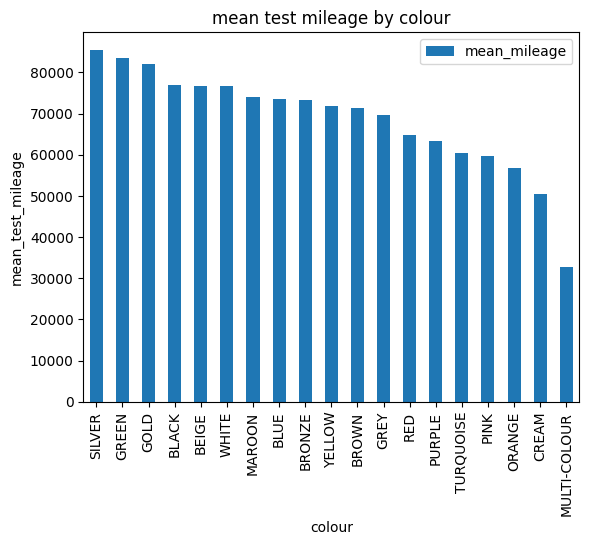

In [32]:
import matplotlib.pyplot as plt

(mean_mileage.plot(title='mean test mileage by colour', kind='bar', x='colour', y='mean_mileage')
            .set(xlabel='colour', ylabel='mean_test_mileage'))


```r
library(ggplot2)

gplot(mean_mileage, aes(x = reorder(colour, -mean_mileage), y = mean_mileage)) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_text(aes(label = round(mean_mileage, 0)), vjust = 1, angle = 45) +
  labs(
    title = "Mean Mileage by Car Colour",
    x = "Car Colour",
    y = "Mean Mileage"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
```